In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import math

In [2]:
from google.colab import drive

drive.mount('/content/drive')

folder = "/content/drive/MyDrive/CVL/assignment_1/"

Mounted at /content/drive


In [7]:
def psnr(img1, img2):
    img1 = img1.convert("L")
    img2 = img2.convert("L")

    mse = 0

    for x in range(img1.width):
        for y in range(img1.height):
            p1 = img1.getpixel((x, y))
            p2 = img2.getpixel((x, y))
            mse += (p1 - p2) ** 2

    mse = mse / (img1.width * img1.height)

    if mse == 0:
        return float("inf")

    return 10 * math.log10((255 ** 2) / mse)

# Dark Image


**Gamma Transformation**



digunakan untuk meningkatkan intensitas pixel yang gelap menjadi terang

In [5]:
def gamma_transform(image, gamma):
    image = image.convert("L")
    output = Image.new("L", image.size)

    for x in range(image.width):
        for y in range(image.height):
            r = image.getpixel((x, y)) / 255
            s = 255 * (r ** gamma)

            output.putpixel((x, y), int(s))

    return output

PSNR Original vs Enhanced : 13.0 dB


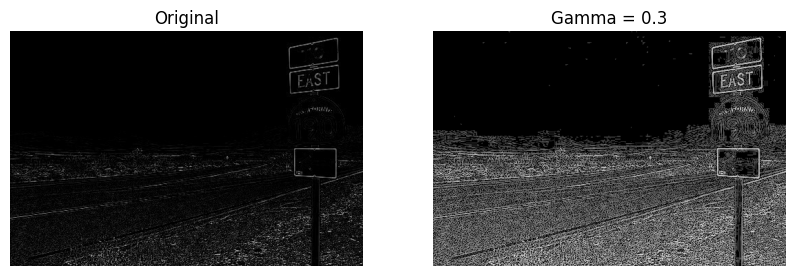

In [9]:
image = Image.open(folder + "dark_image.jpg")

hasil = gamma_transform(image, 0.3)  # semakin kecil gamma, semakin terang

psnr_score = psnr(image, hasil)

print("PSNR Original vs Enhanced :", round(psnr_score, 2), "dB")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap="gray")
plt.title("Gamma = 0.3")
plt.axis("off")

plt.show()

**Log Transformation**

digunakan dengan cara memperjelas detail pada area yang gelap dan menekan perubahan pada yang sudah terang

In [ ]:
def log_transform(image):
    image = image.convert("L")
    output = Image.new("L", image.size)

    c = 255 / math.log(256)

    for x in range(image.width):
        for y in range(image.height):
            r = image.getpixel((x, y))
            s = c * math.log(1 + r)

            output.putpixel((x, y), int(s))

    return output

PSNR Original vs Log Transformation : 11.8 dB


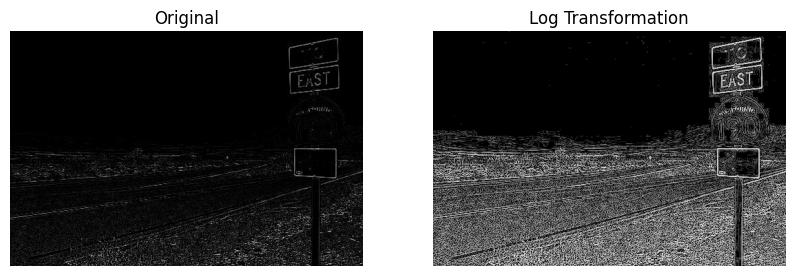

In [11]:
image = Image.open(folder + "dark_image.jpg")

hasil = log_transform(image)

score_psnr = psnr(image, hasil)

print("PSNR Original vs Log Transformation :", round(score_psnr, 2), "dB")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")

plt.show()

perbandingan histogram

In [12]:
def plot_histogram_3(original, gamma_result, log_result):
    original = original.convert("L")
    gamma_result = gamma_result.convert("L")
    log_result = log_result.convert("L")

    plt.figure(figsize=(15, 4))

    # Original
    plt.subplot(1, 3, 1)
    plt.hist(list(original.getdata()), bins=256, range=(0, 256))
    plt.title("Original Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    # Gamma
    plt.subplot(1, 3, 2)
    plt.hist(list(gamma_result.getdata()), bins=256, range=(0, 256))
    plt.title("Gamma Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    # Log
    plt.subplot(1, 3, 3)
    plt.hist(list(log_result.getdata()), bins=256, range=(0, 256))
    plt.title("Log Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

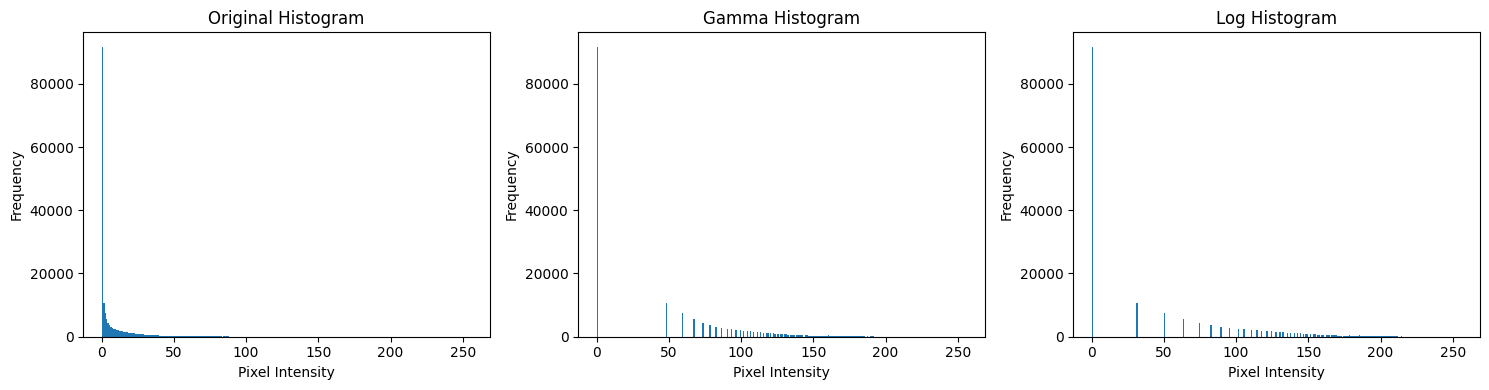

In [13]:
image = Image.open(folder + "dark_image.jpg")

hasil_gamma = gamma_transform(image, 0.3)
hasil_log = log_transform(image)

plot_histogram_3(image, hasil_gamma, hasil_log)

**Contrast Stretching**

digunakan untuk gambar low contrast dengan cara mengambil nilai minimum dan maksimum intensitas lalu melebarkannya ke rentan baru

In [14]:
def contrast_stretching(image):
    image = image.convert("L")
    output = Image.new("L", image.size)

    pixels = list(image.getdata())

    min_val = min(pixels)
    max_val = max(pixels)

    for x in range(image.width):
        for y in range(image.height):
            r = image.getpixel((x, y))

            s = (r - min_val) * 255 / (max_val - min_val)

            output.putpixel((x, y), int(s))

    return output

PSNR Original vs Contrast Stretching : 11.18 dB


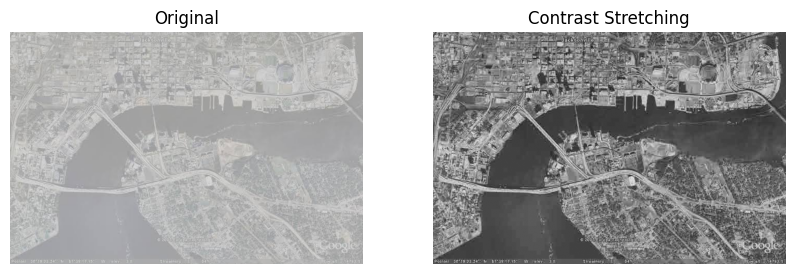

In [16]:
image = Image.open(folder + "lowcon2.jpg")

hasil = contrast_stretching(image)

score_psnr = psnr(image, hasil)

print("PSNR Original vs Contrast Stretching :", round(score_psnr, 2), "dB")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap="gray")
plt.title("Contrast Stretching")
plt.axis("off")

plt.show()

**Laplacian sharpening**

digunakan untuk mendeteksi perubahan intersitas di sekitar pixel yang akan memperukat detail citra yang blur menjadi lebih tajam

In [17]:
def sharpen_image(image):
    image = image.convert("L")
    output = image.copy()

    for x in range(1, image.width - 1):
        for y in range(1, image.height - 1):

            center = image.getpixel((x, y))
            atas = image.getpixel((x, y - 1))
            bawah = image.getpixel((x, y + 1))
            kiri = image.getpixel((x - 1, y))
            kanan = image.getpixel((x + 1, y))

            laplacian = atas + bawah + kiri + kanan - 4 * center
            s = center - laplacian

            s = max(0, min(255, s))
            output.putpixel((x, y), s)

    return output

PSNR Original vs Sharpened : 25.05 dB


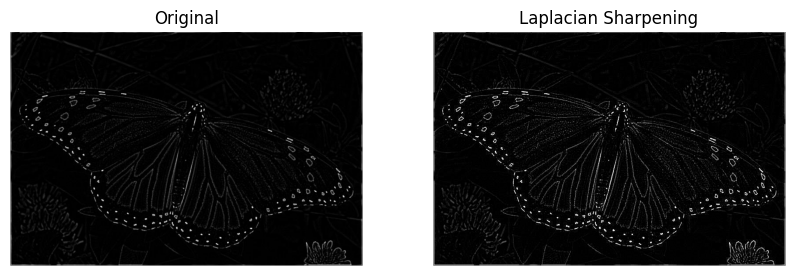

In [19]:
image = Image.open(folder + "blur-image.jpg")

hasil = sharpen_image(image)

score_psnr = psnr(image, hasil)

print("PSNR Original vs Sharpened :", round(score_psnr, 2), "dB")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap="gray")
plt.title("Laplacian Sharpening")
plt.axis("off")

plt.show()

**untuk gambar over_exposure**

PSNR Original vs Enhanced : 14.46 dB


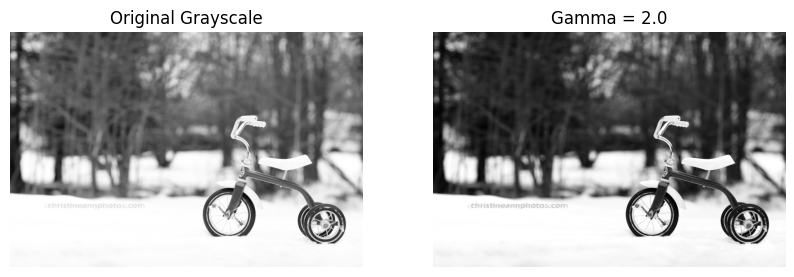

In [20]:
image = Image.open(folder + "overexposed.jpg").convert("L")

hasil = gamma_transform(image, 2.0)  # nilai gamma > 1 jadi lebih gelap

score_psnr = psnr(image, hasil)

print("PSNR Original vs Enhanced :", round(score_psnr, 2), "dB")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap="gray")
plt.title("Gamma = 2.0")
plt.axis("off")

plt.show()

**Noisy Image**

untuk gambar dengan noise salt n pepper. Median filter

In [21]:
def median_filter(image):
    image = image.convert("L")
    output = image.copy()

    for x in range(1, image.width - 1):
        for y in range(1, image.height - 1):

            pixels = []

            for i in range(-1, 2):
                for j in range(-1, 2):
                    pixels.append(
                        image.getpixel((x + i, y + j))
                    )

            pixels.sort()
            median = pixels[4]

            output.putpixel((x, y), median)

    return output

PSNR Original vs Median Filter : 11.62 dB


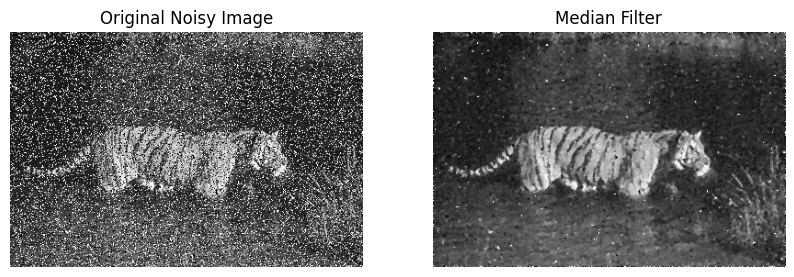

In [22]:
image = Image.open(folder + "sp-noise.png").convert("L")

hasil = median_filter(image)

score_psnr = psnr(image, hasil)

print("PSNR Original vs Median Filter :", round(score_psnr, 2), "dB")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Noisy Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.show()

**Histogram Equalization**

In [23]:
def histogram_equalization(image):
    image = image.convert("L")
    output = Image.new("L", image.size)

    pixels = list(image.getdata())
    total = len(pixels)

    # Hitung frekuensi setiap intensitas
    histogram = [0] * 256

    for pixel in pixels:
        histogram[pixel] += 1

    # Hitung cumulative distribution
    cumulative = 0
    mapping = [0] * 256

    for i in range(256):
        cumulative += histogram[i]
        mapping[i] = int(255 * cumulative / total)

    # Ubah nilai pixel
    for x in range(image.width):
        for y in range(image.height):
            r = image.getpixel((x, y))
            output.putpixel((x, y), mapping[r])

    return output

PSNR Original vs Contrast Stretching : 25.19 dB
PSNR Original vs Histogram Equalization : 7.23 dB


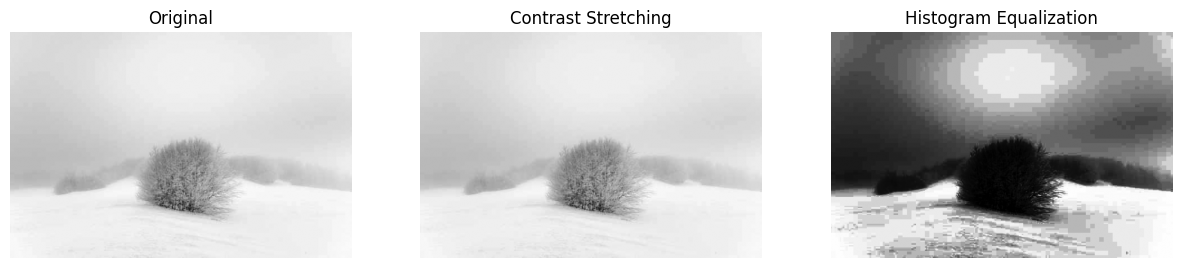

In [24]:
image = Image.open(folder + "lowcont1.jpg").convert("L")

hasil_stretching = contrast_stretching(image)
hasil_histogram = histogram_equalization(image)

psnr_stretching = psnr(image, hasil_stretching)
psnr_histogram = psnr(image, hasil_histogram)

print("PSNR Original vs Contrast Stretching :", round(psnr_stretching, 2), "dB")
print("PSNR Original vs Histogram Equalization :", round(psnr_histogram, 2), "dB")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hasil_stretching, cmap="gray")
plt.title("Contrast Stretching")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hasil_histogram, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.show()